# 01 - Mushroom classification met Random Forest

**Auteur:** Brent Van Gelder  
**Dataset:** `mushroom_project_dataset.csv`  
**Doel:** voorspellen of een paddenstoel eetbaar (`e`) of giftig/onbekend (`p`) is.

> Dit model is uitsluitend een onderwijsproject en mag nooit worden gebruikt om echte paddenstoelen veilig te verklaren.

Deze notebook bevat de volledige eerste workflow in één bestand: data laden, controles, beknopte EDA, een train/validatie/test-split, preprocessing, een Random Forest-baseline en evaluatie. De testset blijft standaard vergrendeld totdat alle modelkeuzes zijn vastgelegd.

## 1. Technologieën en reproduceerbaarheid

We gebruiken `pandas` voor tabulaire data, `seaborn` en `matplotlib` voor grafieken en `scikit-learn` voor de datasplitsing, preprocessing, Random Forest en evaluatie. Alle willekeurige stappen krijgen dezelfde seed.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
DATA_PATH = Path("mushroom_project_dataset.csv")
TARGET = "class"
EDIBLE_LABEL = "e"
POISONOUS_LABEL = "p"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Data laden en valideren

We stoppen vroeg met een duidelijke foutmelding als het bestand of de doelkolom ontbreekt, als labels ontbreken of als er onverwachte klassen voorkomen. Daardoor kan een fout databestand niet stilzwijgend een model opleveren.

In [12]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset niet gevonden: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

if TARGET not in df.columns:
    raise ValueError(f"Doelkolom '{TARGET}' ontbreekt. Aanwezige kolommen: {df.columns.tolist()}")
if df[TARGET].isna().any():
    raise ValueError("De doelkolom bevat ontbrekende waarden.")

observed_labels = set(df[TARGET].unique())
expected_labels = {EDIBLE_LABEL, POISONOUS_LABEL}
if observed_labels != expected_labels:
    raise ValueError(f"Onverwachte labels: {observed_labels}; verwacht: {expected_labels}")

print(f"Rijen: {len(df):,}")
print(f"Kolommen: {df.shape[1]}")
print(f"Exact dubbele rijen: {df.duplicated().sum()}")
display(df.head())

Rijen: 5,000
Kolommen: 13
Exact dubbele rijen: 0


,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,jumbled_noise_0,jumbled_noise_1,class
0,NaN,6.42,13.51,NaN,NaN,d,u,g,x,NaN,x,c,p
1,6.99,7.68,18.76,NaN,w,d,a,f,f,s,f,f,e
2,5.78,7.67,8.21,NaN,r,d,u,f,c,NaN,c,x,p
3,6.34,8.34,11.06,NaN,NaN,d,a,z,x,NaN,x,b,p
4,NaN,5.67,12.78,NaN,n,d,NaN,f,x,NaN,s,s,e


## 3. Beknopte exploratie

Eerst bekijken we de klassendistributie, datatypes en ontbrekende waarden. Dit bepaalt welke preprocessing nodig is. Een gewone accuracy kan bij ongelijke klassen misleidend zijn, dus evalueren we later ook balanced accuracy en de precision/recall van de giftige klasse.

,aantal,percentage
klasse,,
e,3107,62.1
p,1893,37.9


,datatype,ontbrekend_aantal,ontbrekend_percentage,unieke_waarden
spore-print-color,object,4740,94.8,7
stem-surface,object,3359,67.2,8
cap-diameter,float64,2032,40.6,1238
stem-height,float64,1013,20.3,1086
habitat,object,1004,20.1,8
gill-color,object,989,19.8,12
season,object,973,19.5,4
ring-type,object,577,11.5,8
cap-shape,object,406,8.1,7
jumbled_noise_1,object,406,8.1,7


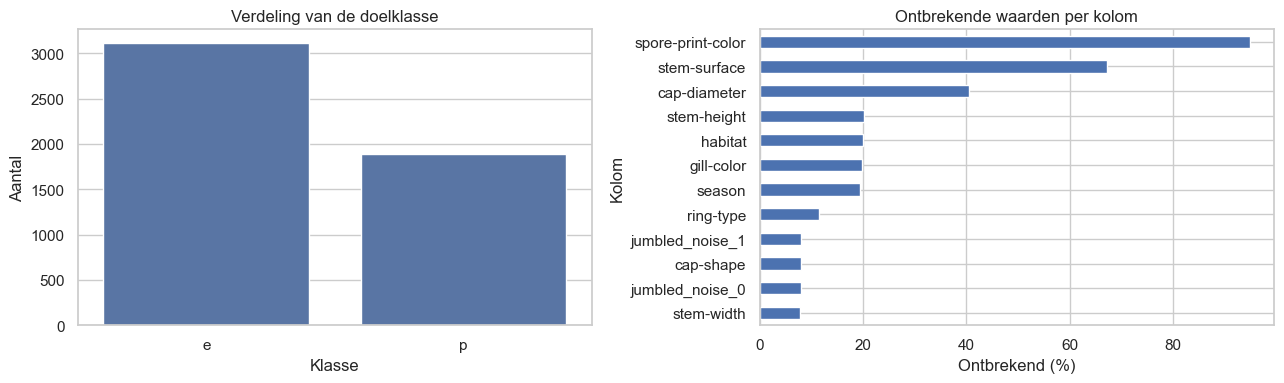

In [13]:
class_summary = (
    df[TARGET]
    .value_counts()
    .rename_axis("klasse")
    .to_frame("aantal")
)
class_summary["percentage"] = (100 * class_summary["aantal"] / len(df)).round(1)
display(class_summary)

missing_summary = pd.DataFrame({
    "datatype": df.dtypes.astype(str),
    "ontbrekend_aantal": df.isna().sum(),
    "ontbrekend_percentage": (100 * df.isna().mean()).round(1),
    "unieke_waarden": df.nunique(dropna=True),
}).sort_values("ontbrekend_percentage", ascending=False)
display(missing_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x=TARGET, order=[EDIBLE_LABEL, POISONOUS_LABEL], ax=axes[0])
axes[0].set(title="Verdeling van de doelklasse", xlabel="Klasse", ylabel="Aantal")
missing_summary.query("ontbrekend_aantal > 0")["ontbrekend_percentage"].sort_values().plot.barh(ax=axes[1])
axes[1].set(title="Ontbrekende waarden per kolom", xlabel="Ontbrekend (%)", ylabel="Kolom")
plt.tight_layout()
plt.show()

### Numerieke verdelingen en verdachte ruiskolommen

De numerieke verdelingen helpen uitschieters zichtbaar te maken. De twee kolommen met `jumbled_noise` in hun naam lijken bewust toegevoegde ruis. In deze eerste baseline laten we ze weg en leggen we die keuze expliciet vast. Later kunnen we gecontroleerd vergelijken of dat besluit de validatiescore beïnvloedt.

,count,mean,std,min,25%,50%,75%,max
cap-diameter,2968.0,7.161439,5.985060,0.5,3.83,6.14,8.785,57.40
stem-height,3987.0,6.693832,3.454998,0.0,4.80,6.01,7.740,32.43
stem-width,4605.0,12.885110,10.610543,0.0,5.94,11.28,17.050,102.48


Kolommen die als expliciete ruis worden uitgesloten: ['jumbled_noise_0', 'jumbled_noise_1']


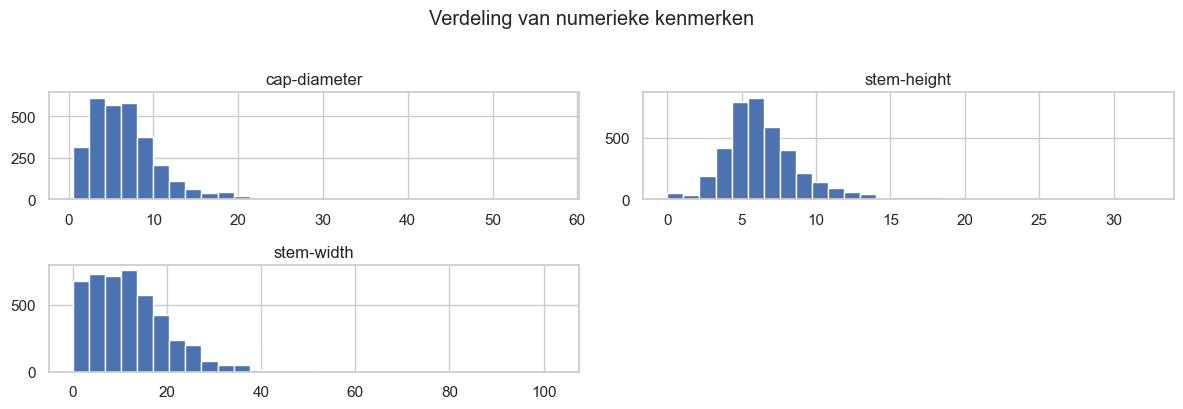

In [14]:
numeric_columns_all = df.drop(columns=TARGET).select_dtypes(include=np.number).columns.tolist()
noise_columns = [column for column in df.columns if column.startswith("jumbled_noise_")]

display(df[numeric_columns_all].describe().T)
print(f"Kolommen die als expliciete ruis worden uitgesloten: {noise_columns}")

if numeric_columns_all:
    df[numeric_columns_all].hist(figsize=(12, 4), bins=30)
    plt.suptitle("Verdeling van numerieke kenmerken", y=1.02)
    plt.tight_layout()
    plt.show()

## 4. Train-, validatie- en testset

We gebruiken 70% training, 15% validatie en 15% test. `stratify` bewaart ongeveer dezelfde klasseverhouding in elke deelset. Alleen de trainingsset wordt gebruikt om preprocessing en modelparameters te leren. De validatieset dient voor modelkeuzes; de testset blijft onaangeraakt voor de definitieve evaluatie.

In [15]:
model_df = df.drop(columns=noise_columns).copy()
X = model_df.drop(columns=TARGET)
y = model_df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "rijen": [len(X_train), len(X_validation), len(X_test)],
    "aandeel_dataset": [len(X_train) / len(X), len(X_validation) / len(X), len(X_test) / len(X)],
    "aandeel_giftig": [
        (y_train == POISONOUS_LABEL).mean(),
        (y_validation == POISONOUS_LABEL).mean(),
        (y_test == POISONOUS_LABEL).mean(),
    ],
}, index=["train", "validatie", "test"])
display(split_summary.style.format({"aandeel_dataset": "{:.1%}", "aandeel_giftig": "{:.1%}"}))

,rijen,aandeel_dataset,aandeel_giftig
train,3500,70.0%,37.9%
validatie,750,15.0%,37.9%
test,750,15.0%,37.9%


## 5. Lekvrije preprocessing en Random Forest

Numerieke ontbrekende waarden worden vervangen door de mediaan van uitsluitend de trainingsset. Categorische ontbrekende waarden krijgen een expliciete categorie en onbekende waarden worden veilig verwerkt. De `Pipeline` zorgt dat deze stappen bij training en voorspelling exact hetzelfde verlopen.

De Random Forest gebruikt meerdere beslissingsbomen en middelt hun voorspellingen. `class_weight='balanced_subsample'` compenseert de ongelijke klasseverdeling binnen elke bootstrap-steekproef. Dit is een eerste baseline; hyperparameters worden pas na gezamenlijke keuze getuned.

In [16]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)

random_forest = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", random_forest),
])

baseline_model.fit(X_train, y_train)
print("Random Forest getraind op de trainingsset.")

Random Forest getraind op de trainingsset.


## 6. Evaluatiefunctie

Omdat een giftige paddenstoel ten onrechte als eetbaar voorspellen het ernstigste type fout is, rapporteren we de giftige klasse expliciet als positieve klasse. Recall voor `p` laat zien welk aandeel van de werkelijk giftige gevallen wordt gevonden. Precision laat zien welk aandeel van de waarschuwingen werkelijk giftig is.

In [17]:
def evaluate_classifier(fitted_model, X_eval, y_eval, split_name):
    predictions = fitted_model.predict(X_eval)
    poisonous_index = list(fitted_model.classes_).index(POISONOUS_LABEL)
    poisonous_probability = fitted_model.predict_proba(X_eval)[:, poisonous_index]
    y_binary = (y_eval == POISONOUS_LABEL).astype(int)

    metrics = pd.Series({
        "accuracy": accuracy_score(y_eval, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_eval, predictions),
        "precision_giftig": precision_score(y_eval, predictions, pos_label=POISONOUS_LABEL, zero_division=0),
        "recall_giftig": recall_score(y_eval, predictions, pos_label=POISONOUS_LABEL, zero_division=0),
        "f1_giftig": f1_score(y_eval, predictions, pos_label=POISONOUS_LABEL, zero_division=0),
        "f2_giftig": fbeta_score(y_eval, predictions, beta=2, pos_label=POISONOUS_LABEL, zero_division=0),
        "roc_auc": roc_auc_score(y_binary, poisonous_probability),
        "average_precision": average_precision_score(y_binary, poisonous_probability),
    }, name=split_name)

    print(f"Evaluatie: {split_name}")
    display(metrics.to_frame().T.style.format("{:.3f}"))
    print(classification_report(
        y_eval,
        predictions,
        labels=[EDIBLE_LABEL, POISONOUS_LABEL],
        target_names=["eetbaar", "giftig/onbekend"],
        zero_division=0,
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_eval,
        predictions,
        labels=[EDIBLE_LABEL, POISONOUS_LABEL],
        display_labels=["eetbaar", "giftig/onbekend"],
        cmap="Blues",
    )
    plt.title(f"Confusion matrix - {split_name}")
    plt.grid(False)
    plt.show()
    return metrics


## 7. Validatieresultaten

Alle eerste modelbeslissingen worden gebaseerd op de validatieset. We bekijken vooral hoeveel giftige gevallen worden gemist in de confusion matrix.

Evaluatie: baseline_validatie


,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
baseline_validatie,0.792,0.753,0.808,0.592,0.683,0.625,0.834,0.772


                 precision    recall  f1-score   support

        eetbaar       0.79      0.91      0.85       466
giftig/onbekend       0.81      0.59      0.68       284

       accuracy                           0.79       750
      macro avg       0.80      0.75      0.76       750
   weighted avg       0.79      0.79      0.78       750



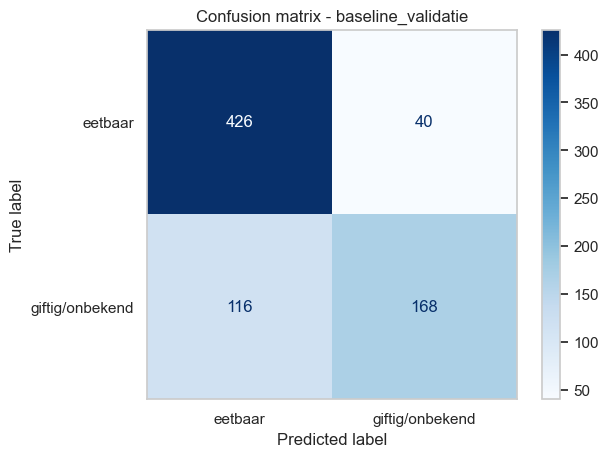

In [18]:
validation_metrics = evaluate_classifier(
    baseline_model, X_validation, y_validation, split_name="baseline_validatie"
)

## 8. Hyperparameters tunen met RandomizedSearchCV

`RandomizedSearchCV` probeert 24 reproduceerbaar gelote combinaties. Elke combinatie wordt alleen binnen de trainingsset beoordeeld met vijfvoudige gestratificeerde cross-validatie. De validatieset blijft buiten deze zoektocht en controleert daarna of de verbetering generaliseert.

Als hoofdscore gebruiken we F2 voor de giftige klasse. F2 weegt recall vier keer zo zwaar als precision. Daardoor telt het missen van een giftige paddenstoel zwaarder, terwijl een model dat alles als giftig markeert nog steeds wordt afgestraft.

In [19]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f2_poisonous_scorer = make_scorer(
    fbeta_score, beta=2, pos_label=POISONOUS_LABEL, zero_division=0
)
recall_poisonous_scorer = make_scorer(
    recall_score, pos_label=POISONOUS_LABEL, zero_division=0
)

parameter_distributions = {
    "classifier__n_estimators": [200, 300, 500, 700],
    "classifier__max_depth": [None, 8, 12, 18, 25],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2", 0.5],
    "classifier__class_weight": [
        "balanced",
        "balanced_subsample",
        {EDIBLE_LABEL: 1.0, POISONOUS_LABEL: 1.5},
        {EDIBLE_LABEL: 1.0, POISONOUS_LABEL: 2.0},
        {EDIBLE_LABEL: 1.0, POISONOUS_LABEL: 3.0},
    ],
    "classifier__max_samples": [None, 0.7, 0.9],
}

search_estimator = clone(baseline_model).set_params(classifier__n_jobs=1)
random_search = RandomizedSearchCV(
    estimator=search_estimator,
    param_distributions=parameter_distributions,
    n_iter=24,
    scoring={
        "f2_giftig": f2_poisonous_scorer,
        "recall_giftig": recall_poisonous_scorer,
        "balanced_accuracy": "balanced_accuracy",
    },
    refit="f2_giftig",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)

random_search.fit(X_train, y_train)
tuned_model = random_search.best_estimator_.set_params(classifier__n_jobs=-1)
print(f"Beste gemiddelde CV F2-score: {random_search.best_score_:.3f}")
print("Beste hyperparameters:")
display(pd.Series(random_search.best_params_, name="waarde").to_frame())

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Beste gemiddelde CV F2-score: 0.759
Beste hyperparameters:


,waarde
classifier__n_estimators,500
classifier__min_samples_split,10
classifier__min_samples_leaf,4
classifier__max_samples,0.9
classifier__max_features,sqrt
classifier__max_depth,18
classifier__class_weight,"{'e': 1.0, 'p': 3.0}"


### Baseline en getuned model vergelijken op de validatieset

De cross-validatiescore kiest de beste zoekconfiguratie. Daarna vergelijken we die configuratie één keer met de baseline op de aparte validatieset. Het model met de hoogste validatie-F2 wordt de kandidaat voor de uiteindelijke testevaluatie.

,rank_test_f2_giftig,mean_test_f2_giftig,std_test_f2_giftig,mean_test_recall_giftig,mean_test_balanced_accuracy,mean_train_f2_giftig,params
3,1,0.759094,0.010399,0.853585,0.692540,0.875244,"{'classifier__n_estimators': 500, 'classifier_..."
13,2,0.757092,0.007286,0.886038,0.648766,0.831641,"{'classifier__n_estimators': 200, 'classifier_..."
10,3,0.750306,0.013719,0.821132,0.712175,0.898163,"{'classifier__n_estimators': 500, 'classifier_..."
5,4,0.746405,0.009816,0.800755,0.728883,0.893370,"{'classifier__n_estimators': 200, 'classifier_..."
20,5,0.735288,0.015792,0.766038,0.748076,0.923139,"{'classifier__n_estimators': 700, 'classifier_..."
14,6,0.691402,0.018483,0.680755,0.766814,0.927871,"{'classifier__n_estimators': 700, 'classifier_..."
15,7,0.686501,0.017272,0.689057,0.744528,0.873413,"{'classifier__n_estimators': 700, 'classifier_..."
19,8,0.683602,0.017567,0.680755,0.749803,0.891752,"{'classifier__n_estimators': 700, 'classifier_..."
6,9,0.682061,0.020555,0.673208,0.757293,0.908723,"{'classifier__n_estimators': 200, 'classifier_..."
12,10,0.669561,0.022137,0.647547,0.766762,0.929399,"{'classifier__n_estimators': 500, 'classifier_..."


Evaluatie: getuned_validatie


,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
getuned_validatie,0.660,0.696,0.532,0.845,0.653,0.756,0.815,0.763


                 precision    recall  f1-score   support

        eetbaar       0.85      0.55      0.67       466
giftig/onbekend       0.53      0.85      0.65       284

       accuracy                           0.66       750
      macro avg       0.69      0.70      0.66       750
   weighted avg       0.73      0.66      0.66       750



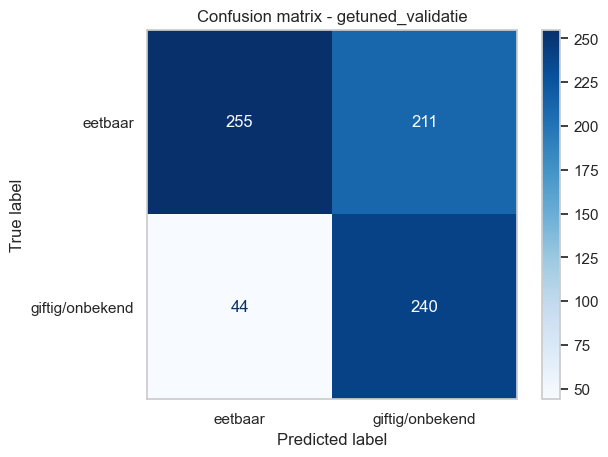

,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
baseline_validatie,0.792,0.753,0.808,0.592,0.683,0.625,0.834,0.772
getuned_validatie,0.660,0.696,0.532,0.845,0.653,0.756,0.815,0.763


Geselecteerde kandidaat op basis van validatie-F2: getuned Random Forest


In [20]:
cv_results = (
    pd.DataFrame(random_search.cv_results_)
    .sort_values("rank_test_f2_giftig")
)
display(cv_results[[
    "rank_test_f2_giftig",
    "mean_test_f2_giftig",
    "std_test_f2_giftig",
    "mean_test_recall_giftig",
    "mean_test_balanced_accuracy",
    "mean_train_f2_giftig",
    "params",
]].head(10))

tuned_validation_metrics = evaluate_classifier(
    tuned_model, X_validation, y_validation, split_name="getuned_validatie"
)
validation_comparison = pd.DataFrame([validation_metrics, tuned_validation_metrics])
display(validation_comparison.style.format("{:.3f}"))

if tuned_validation_metrics["f2_giftig"] >= validation_metrics["f2_giftig"]:
    selected_model = tuned_model
    selected_model_name = "getuned Random Forest"
else:
    selected_model = baseline_model
    selected_model_name = "baseline Random Forest"

print(f"Geselecteerde kandidaat op basis van validatie-F2: {selected_model_name}")

## 9. Verklaarbaarheid met feature importance

De ingebouwde Random Forest-importance geeft een eerste indicatie van welke getransformeerde kenmerken het model gebruikt. Deze waarden tonen modelgebruik, geen oorzaak-gevolgrelatie. Ze kunnen bovendien voorkeur hebben voor kenmerken met veel mogelijke splitsingen.

,feature,importance
2,stem-width,0.170055
1,stem-height,0.148524
0,cap-diameter,0.095569
64,stem-surface_s,0.036984
51,cap-shape_b,0.025622
58,stem-surface___missing__,0.020688
49,ring-type_z,0.020220
60,stem-surface_g,0.019649
57,cap-shape_x,0.019309
25,gill-color_w,0.019062


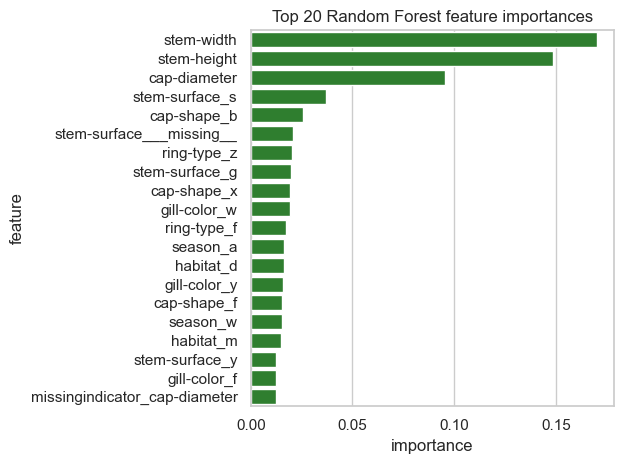

In [21]:
feature_names = selected_model.named_steps["preprocessor"].get_feature_names_out()
feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": selected_model.named_steps["classifier"].feature_importances_,
    })
    .sort_values("importance", ascending=False)
)

display(feature_importance.head(20))
sns.barplot(
    data=feature_importance.head(20),
    x="importance",
    y="feature",
    color="forestgreen",
)
plt.title("Top 20 Random Forest feature importances")
plt.tight_layout()
plt.show()

## 10. Definitieve testset - voorlopig vergrendeld

Voer deze evaluatie pas uit nadat preprocessing, hyperparameters, beslisdrempel en evaluatiemaatstaf definitief gekozen zijn. Zet dan één keer `RUN_FINAL_TEST` op `True`. Als we na het bekijken van de testscore opnieuw keuzes aanpassen, is dit geen werkelijk onafhankelijke testset meer.

In [22]:
RUN_FINAL_TEST = False

if RUN_FINAL_TEST:
    print(f"Definitief gekozen model: {selected_model_name}")
    test_metrics = evaluate_classifier(selected_model, X_test, y_test, split_name="test")
else:
    print("Testset niet geëvalueerd: leg eerst alle modelkeuzes vast.")

Testset niet geëvalueerd: leg eerst alle modelkeuzes vast.


## 11. Huidige conclusie en volgende beslissing

Deze baseline geeft ons een reproduceerbaar vertrekpunt. Noteer hier na uitvoering de belangrijkste validatiescore, het aantal gemiste giftige gevallen en wat de feature importance laat zien.

**Nog gezamenlijk te beslissen voordat de testset wordt geopend:**

1. eventueel aanpassen van de waarschijnlijkheidsdrempel om minder giftige gevallen te missen;
2. vergelijking mét en zonder de twee vermoedelijke ruiskolommen;
3. pas daarna het gekozen model en de beslisdrempel bevriezen en de testset één keer openen.